In [5]:
pip install pandas numpy nltk scikit-learn matplotlib

  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install sentence-transformers

In [7]:
pip install faiss-cpu

   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
    --------------------------------------- 0.3/16.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.2 MB 2.1 MB/s eta 0:00:08
   -- ------------------------------------- 1.0/16.2 MB 2.0 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/16.2 MB 2.4 MB/s eta 0:00:06
   ----- ---------------------------------- 2.4/16.2 MB 2.5 MB/s eta 0:00:06
   ------- -------------------------------- 3.1/16.2 MB 2.8 MB/s eta 0:00:05
   --------- ------------------------------ 3.7/16.2 MB 2.8 MB/s eta 0:00:05
   ----------- ---------------------------- 4.5/16.2 MB 3.0 MB/s eta 0:00:04
   ------------- -------------------------- 5.5/16.2 MB 3.1 MB/s eta 0:00:04
   --------------- ------------------------ 6.3/16.2 MB 3.2 MB/s eta 0:00:04
   ----------------- ---------------------- 7.1/16.2 MB 3.3 MB/s eta 0:00:03
   -------------------- ------------------- 8.1/16.2 MB 3.4 MB/s eta 0:00:03
   ----------

In [8]:
pip install transformers==4.52.4

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.5 MB 2.8 MB/s eta 0:00:01
   --------------- ------------------------ 1.3/3.5 MB 2.9 MB/s eta 0:00:01
   ------------------------ --------------- 2.1/3.5 MB 2.9 MB/s eta 0:00:01
   --------------------------------- ------ 2.9/3.5 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 3.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/

In [11]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.2 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/9.2 MB 4.1 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.2 MB 4.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.2 MB 3.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.2 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.2 MB 3.8 MB/s eta 0:00:02
   -------------------------- ------------- 6.0/9.2 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.2 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.2 MB 3.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.4/9.2 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 3.8 MB/s  0:00:02
   --------------------------

In [12]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np

import nltk
import re

import faiss

from sentence_transformers import SentenceTransformer

from transformers import pipeline

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [14]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...


True

In [15]:
df = pd.read_csv("brain_tumor_research_paper.csv")

In [16]:
df.head()

,Section_ID,Section_Title,Content
0,1,Title,Deep Learning-Based Brain Tumor Detection Usin...
1,2,Abstract,Brain tumor detection is one of the most impor...
2,3,Keywords,"Brain Tumor, Deep Learning, MRI, CNN, ResNet50..."
3,4,Introduction,Brain tumors are abnormal growths of cells ins...
4,5,Problem Statement,Traditional diagnosis relies heavily on radiol...


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Section_ID     24 non-null     int64 
 1   Section_Title  24 non-null     object
 2   Content        24 non-null     object
dtypes: int64(1), object(2)
memory usage: 704.0+ bytes


In [18]:
df.isnull().sum()

Section_ID       0
Section_Title    0
Content          0
dtype: int64

In [19]:
df["text"] = df["Section_Title"] + ". " + df["Content"]

In [20]:
df[["Section_Title","text"]].head()

,Section_Title,text
0,Title,Title. Deep Learning-Based Brain Tumor Detecti...
1,Abstract,Abstract. Brain tumor detection is one of the ...
2,Keywords,"Keywords. Brain Tumor, Deep Learning, MRI, CNN..."
3,Introduction,Introduction. Brain tumors are abnormal growth...
4,Problem Statement,Problem Statement. Traditional diagnosis relie...


In [21]:
def clean_text(text):

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    return text

In [22]:
df["clean_text"] = df["text"].apply(clean_text)

In [23]:
df["tokens"] = df["clean_text"].apply(word_tokenize)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\NAINA GAUR/nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [24]:
df["tokens"].head()

KeyError: 'tokens'

In [25]:
stop_words = set(stopwords.words("english"))

In [26]:
df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

KeyError: 'tokens'

In [27]:
print(df.columns)

Index(['Section_ID', 'Section_Title', 'Content', 'text', 'clean_text'], dtype='object')


In [28]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\NAINA GAUR/nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [30]:
df[["clean_text", "tokens"]].head()

KeyError: "['tokens'] not in index"

In [31]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\NAINA GAUR/nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [32]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [33]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

In [34]:
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,Title Deep LearningBased Brain Tumor Detection...,"[Title, Deep, LearningBased, Brain, Tumor, Det..."
1,Abstract Brain tumor detection is one of the m...,"[Abstract, Brain, tumor, detection, is, one, o..."
2,Keywords Brain Tumor Deep Learning MRI CNN Res...,"[Keywords, Brain, Tumor, Deep, Learning, MRI, ..."
3,Introduction Brain tumors are abnormal growths...,"[Introduction, Brain, tumors, are, abnormal, g..."
4,Problem Statement Traditional diagnosis relies...,"[Problem, Statement, Traditional, diagnosis, r..."


In [35]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [36]:
df["tokens"].head()

0    [Title, Deep, LearningBased, Brain, Tumor, Det...
1    [Abstract, Brain, tumor, detection, one, impor...
2    [Keywords, Brain, Tumor, Deep, Learning, MRI, ...
3    [Introduction, Brain, tumors, abnormal, growth...
4    [Problem, Statement, Traditional, diagnosis, r...
Name: tokens, dtype: object

In [37]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [38]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [39]:
df["tokens"].head()

0    [Title, Deep, LearningBased, Brain, Tumor, Det...
1    [Abstract, Brain, tumor, detection, one, impor...
2    [Keywords, Brain, Tumor, Deep, Learning, MRI, ...
3    [Introduction, Brain, tumor, abnormal, growth,...
4    [Problem, Statement, Traditional, diagnosis, r...
Name: tokens, dtype: object

In [40]:
df["processed_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [41]:
df["processed_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [42]:
df[["Section_Title", "processed_text"]].head()

,Section_Title,processed_text
0,Title,Title Deep LearningBased Brain Tumor Detection...
1,Abstract,Abstract Brain tumor detection one important a...
2,Keywords,Keywords Brain Tumor Deep Learning MRI CNN Res...
3,Introduction,Introduction Brain tumor abnormal growth cell ...
4,Problem Statement,Problem Statement Traditional diagnosis relies...


In [43]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x.split()))

df[["Section_Title", "word_count"]]

,Section_Title,word_count
0,Title,9
1,Abstract,37
2,Keywords,13
3,Introduction,36
4,Problem Statement,24
5,Objectives,19
6,Literature Review,22
7,Artificial Intelligence,21
8,Machine Learning,15
9,Deep Learning,16


In [44]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x.split()))

df[["Section_Title", "word_count"]]

,Section_Title,word_count
0,Title,9
1,Abstract,37
2,Keywords,13
3,Introduction,36
4,Problem Statement,24
5,Objectives,19
6,Literature Review,22
7,Artificial Intelligence,21
8,Machine Learning,15
9,Deep Learning,16


In [45]:
df.to_csv("processed_research_paper.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [46]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model Loaded Successfully")

Model Loaded Successfully


In [47]:
embeddings = model.encode(df["processed_text"].tolist())

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (24, 384)


In [48]:
import numpy as np
import faiss

embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("FAISS Index Created:", index.ntotal)

FAISS Index Created: 24


In [49]:
def search_papers(query, top_k=3):

    query_vec = model.encode([query]).astype("float32")

    distances, indices = index.search(query_vec, top_k)

    print("\n Query:", query)
    print("="*60)

    for i in indices[0]:
        print("\n Title:", df.iloc[i]["Section_Title"])
        print("\n Content Preview:")
        print(df.iloc[i]["Content"][:300])
        print("-"*60)

In [50]:
search_papers("brain tumor detection using CNN")


 Query: brain tumor detection using CNN

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------


In [51]:
search_papers("brain tumor detection using CNN")


 Query: brain tumor detection using CNN

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------


In [52]:
search_papers("MRI medical imaging deep learning")


 Query: MRI medical imaging deep learning

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Conclusion

 Content Preview:
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diagnosis.
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------


In [53]:
search_papers("brain tumor detection CNN", top_k=5)


 Query: brain tumor detection CNN

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------

 Title: Objectives

 Content Preview:
The objectives of this study are to develop a CNN-based brain tumor detection model, compare transfer learning models such as ResNet50 and VGG16, and evaluate their class

In [54]:
search_papers("deep learning MRI tumor detection", top_k=3)
search_papers("traditional medical diagnosis brain tumor", top_k=3)


 Query: deep learning MRI tumor detection

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Conclusion

 Content Preview:
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diagnosis.
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------

 Query: traditional medical diagnosis brain tumor

 Title: Introduction

 Content Preview:
Brain

In [55]:
def search_papers_with_score(query, top_k=3):

    query_vec = model.encode([query]).astype("float32")

    distances, indices = index.search(query_vec, top_k)

    print("\nQuery:", query)
    print("="*60)

    for i, idx in enumerate(indices[0]):
        print("\nRank:", i+1)
        print("Title:", df.iloc[idx]["Section_Title"])
        print("Distance Score:", distances[0][i])
        print("Preview:", df.iloc[idx]["Content"][:200])
        print("-"*60)

In [56]:
search_papers_with_score("CNN brain tumor detection")


Query: CNN brain tumor detection

Rank: 1
Title: Title
Distance Score: 0.522152
Preview: Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

Rank: 2
Title: Keywords
Distance Score: 0.59836274
Preview: Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

Rank: 3
Title: Abstract
Distance Score: 0.7016803
Preview: Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain 
------------------------------------------------------------


In [57]:
search_papers("CNN", top_k=3)
search_papers("convolutional neural network for medical imaging", top_k=3)


 Query: CNN

 Title: Model Architecture

 Content Preview:
The proposed CNN model contains convolution layers followed by ReLU activation, max pooling, dropout layers, flattening, dense layers, and a softmax output layer.
------------------------------------------------------------

 Title: Convolutional Neural Network

 Content Preview:
CNN is specifically designed for image analysis. It consists of convolution layers, pooling layers, activation functions, and fully connected layers.
------------------------------------------------------------

 Title: References

 Content Preview:
Goodfellow et al. Deep Learning (2016); He et al. Deep Residual Learning for Image Recognition (2016); Simonyan and Zisserman. Very Deep Convolutional Networks (2015).
------------------------------------------------------------

 Query: convolutional neural network for medical imaging

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in m

In [58]:
search_papers("what is overfitting in medical AI models", top_k=3)


 Query: what is overfitting in medical AI models

 Title: Artificial Intelligence

 Content Preview:
Artificial Intelligence enables machines to simulate human intelligence and solve complex problems. AI is widely used in healthcare for diagnosis, prediction, and decision support systems.
------------------------------------------------------------

 Title: Limitations

 Content Preview:
Model performance depends on dataset quality and quantity. MRI image variations and class imbalance may reduce prediction accuracy.
------------------------------------------------------------

 Title: Future Scope

 Content Preview:
Future work includes Vision Transformers, Explainable AI, Federated Learning, multimodal medical data analysis, and deployment in cloud-based healthcare systems.
------------------------------------------------------------


In [59]:
def search_filtered(query, keyword, top_k=3):

    filtered_df = df[df["processed_text"].str.contains(keyword, case=False)]

    emb = model.encode(filtered_df["processed_text"].tolist()).astype("float32")

    idx = faiss.IndexFlatL2(emb.shape[1])
    idx.add(emb)

    q = model.encode([query]).astype("float32")

    distances, indices = idx.search(q, top_k)

    print("\nFiltered Search for:", keyword)
    print("="*60)

    for i in indices[0]:
        print(filtered_df.iloc[i]["Section_Title"])
        print(filtered_df.iloc[i]["Content"][:200])
        print("-"*60)

In [60]:
search_filtered("CNN architecture in tumor detection", "CNN")


Filtered Search for: CNN
Keywords
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------
Objectives
The objectives of this study are to develop a CNN-based brain tumor detection model, compare transfer learning models such as ResNet50 and VGG16, and evaluate their classification performance.
------------------------------------------------------------
Conclusion
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diag
------------------------------------------------------------


In [61]:
search_papers("deep learning applications in medical imaging", top_k=5)


 Query: deep learning applications in medical imaging

 Title: Conclusion

 Content Preview:
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diagnosis.
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Title

 Content Preview:
De

In [62]:
from transformers import pipeline

qa_model = pipeline("question-answering")
print("QA Model Loaded")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--distilbert--distilbert-base-cased-distilled-squad. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' 

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


QA Model Loaded


In [63]:
context = df["processed_text"].iloc[0]

question = "What is the main topic of this paper?"

result = qa_model(question=question, context=context)

print(result)

{'score': 0.6611599326133728, 'start': 25, 'end': 46, 'answer': 'Brain Tumor Detection'}


In [64]:
def ask_question(question, index=0):

    context = df["processed_text"].iloc[index]

    result = qa_model(question=question, context=context)

    print("\nQuestion:", question)
    print("Answer:", result["answer"])
    print("Confidence:", result["score"])

In [65]:
ask_question("Which method is used?")


Question: Which method is used?
Answer: MRI Images
Confidence: 0.6342424750328064


In [66]:
def smart_qa(question):

    # best document using FAISS search
    query_vec = model.encode([question]).astype("float32")
    _, idx = index.search(query_vec, 1)

    best_index = idx[0][0]

    #  run QA on that document
    context = df["processed_text"].iloc[best_index]

    result = qa_model(question=question, context=context)

    print("\nQuestion:", question)
    print("\nAnswer:", result["answer"])
    print("\nConfidence:", result["score"])
    print("\nSource:", df.iloc[best_index]["Section_Title"])

In [67]:
smart_qa("What is CNN used for in brain tumor detection?")


Question: What is CNN used for in brain tumor detection?

Answer: ResNet50 Medical Imaging Artificial Intelligence Classification

Confidence: 0.28121790289878845

Source: Keywords


In [68]:
from transformers import pipeline

ner = pipeline("ner", grouped_entities=True)

print("NER Model Loaded")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--dbmdz--bert-large-cased-finetuned-conll03-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' 

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


NER Model Loaded


C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\pipelines\token_classification.py:170: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="simple"` instead.
  warnings.warn(


In [69]:
text = df["processed_text"].iloc[0]

entities = ner(text)

for e in entities:
    print(e)

{'entity_group': 'MISC', 'score': np.float32(0.7686334), 'word': 'MRI', 'start': 53, 'end': 56}


In [72]:
def extract_entities(text):

    entities = ner(text)

    print("\n Extracted Entities:\n")

    for e in entities:
        print(f"{e['word']} → {e['entity_group']}")

In [73]:
extract_entities(df["processed_text"].iloc[1])


 Extracted Entities:

MRI → MISC


In [74]:
for i in range(len(df)):

    print("\n==============================")
    print("Section:", df.iloc[i]["Section_Title"])

    extract_entities(df.iloc[i]["processed_text"])


Section: Title

 Extracted Entities:

MRI → MISC

Section: Abstract

 Extracted Entities:

MRI → MISC

Section: Keywords

 Extracted Entities:

Tu → MISC
Deep Learning MRI CNN ResNet50 → MISC
Imaging → MISC
##ial Intelligence Classification → MISC

Section: Introduction

 Extracted Entities:

I → MISC
MRI → MISC
MRI → MISC

Section: Problem Statement

 Extracted Entities:


Section: Objectives

 Extracted Entities:

CNN → MISC
ResNet → ORG

Section: Literature Review

 Extracted Entities:

CNN → ORG
##Net Vision Transformers → ORG

Section: Artificial Intelligence

 Extracted Entities:

Intelligence → MISC
AI → MISC

Section: Machine Learning

 Extracted Entities:

Machine Learning Machine Learning → MISC
Artific → ORG
##ial Intelligence → MISC

Section: Deep Learning

 Extracted Entities:

Learning → MISC

Section: Artificial Neural Network

 Extracted Entities:

Art → MISC
##ial Neural Network → MISC
N → MISC
##al Networks → MISC

Section: Convolutional Neural Network

 Extracted En

In [75]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [76]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')

dtm = vectorizer.fit_transform(df["processed_text"])

In [77]:
lda = LatentDirichletAllocation(n_components=3, random_state=42)

lda.fit(dtm)

print("LDA Model Trained")

LDA Model Trained


In [78]:
def display_topics(model, feature_names, num_words=10):

    for topic_idx, topic in enumerate(model.components_):

        print("\nTopic:", topic_idx + 1)

        print([feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]])

In [79]:
feature_names = vectorizer.get_feature_names_out()

display_topics(lda, feature_names)


Topic: 1
['learning', 'artificial', 'deep', 'intelligence', 'training', 'machine', 'data', 'neural', 'prediction', 'used']

Topic: 2
['learning', 'brain', 'mri', 'model', 'tumor', 'transfer', 'performance', 'detection', 'accuracy', 'image']

Topic: 3
['layer', 'image', 'cnn', 'model', 'data', 'pooling', 'convolution', 'activation', 'output', 'neural']


In [80]:
topic_values = lda.transform(dtm)

df["Topic"] = topic_values.argmax(axis=1)

In [81]:
df[["Section_Title", "Topic"]].head()

,Section_Title,Topic
0,Title,1
1,Abstract,1
2,Keywords,1
3,Introduction,1
4,Problem Statement,1


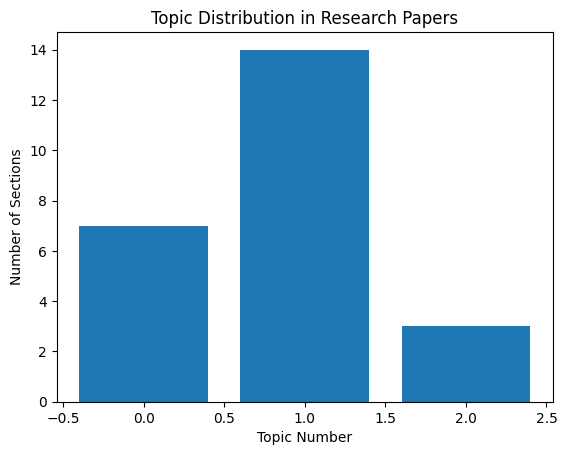

In [82]:
import matplotlib.pyplot as plt

topic_counts = df["Topic"].value_counts()

plt.bar(topic_counts.index, topic_counts.values)
plt.title("Topic Distribution in Research Papers")
plt.xlabel("Topic Number")
plt.ylabel("Number of Sections")
plt.show()

In [83]:
from transformers import pipeline

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

print("Summarizer Loaded")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  36%|###6      | 587M/1.63G [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Summarizer Loaded


In [84]:
text = df["Content"].iloc[0]

summary = summarizer(text[:3000], max_length=150, min_length=50, do_sample=False)

print(summary[0]["summary_text"])

Your max_length is set to 150, but your input_length is only 14. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)


Deep Learning-Based Brain Tumor Detection Using MRI Images. Using MRI images to detect brain tumours. Brain tumours can be identified using a combination of MRI and other techniques. Brain tumors can also be detected using other methods such as PET and CT.


In [85]:
def summarize_text(text):

    summary = summarizer(text[:3000], max_length=120, min_length=40, do_sample=False)

    return summary[0]["summary_text"]

In [86]:
summarize_text(df["Content"].iloc[1])

Your max_length is set to 120, but your input_length is only 53. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=26)


'Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy while reducing manual effort.'